Visual Evaluation

In [ ]:
pwd

'c:\\Users\\bpham\\Documents\\HomeWork\\Pokemon-Card-Authenticator\\notebooks'

In [ ]:
# Changing Directory
%cd ..


c:\Users\bpham\Documents\HomeWork\Pokemon-Card-Authenticator


C:\Users\bpham\AppData\Roaming\Python\Python310\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [17]:
import torch
import random
import matplotlib.pyplot as plt
from src.dataset import test_dataset
from src.utils import make_predictions
from src.model import PokemonCardModelV1





Maiking Predictions

In [14]:
#Device Agnostic Code
device = "cuda" if torch.cuda.is_available() else "cpu"



#Loading Model 
loaded_model = PokemonCardModelV1(input_shape =3, hidden_units = 10, output_shape= 1)

loaded_model.load_state_dict(torch.load("models/pokemon_card_model_v1.pth"))

loaded_model.to(device)


C:\Users\bpham\AppData\Local\Temp\ipykernel_3840\416141493.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("models/pokemon_card_m

PokemonCardModelV1(
  (conv_block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=31360, out_features=1, bias=True)
  )
)

In [69]:
#random.seed(42)

test_samples = []
test_labels =[]

for X,y in random.sample(list(test_dataset), k = 9):
    test_samples.append(X)
    test_labels.append(y)


# Viewing the first sample shape

test_samples[0].shape

torch.Size([3, 224, 224])

In [70]:
pred_probs = make_predictions(model=loaded_model, data= test_samples, device=device)

In [71]:
#Turning Predictions into prediction labels


pred_classes = torch.round(pred_probs).squeeze()
pred_classes


tensor([1., 1., 1., 1., 0., 0., 1., 1., 0.])

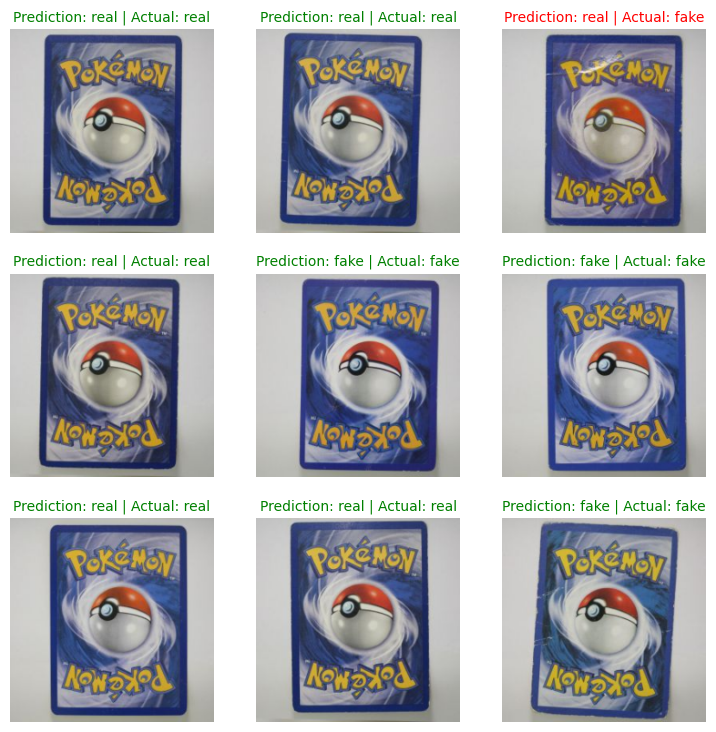

In [72]:
# Plotting the predictions

class_names = test_dataset.classes

plt.figure(figsize = (9,9))

nrows = 3

ncols = 3


for i, sample in enumerate(test_samples):
    plt.subplot(nrows,ncols,i+1)
    plt.imshow(sample.permute(1,2,0))

    pred_label =  class_names[pred_classes[i].to(int)]

    truth_label = class_names[test_labels[i]]

    text = f"Prediction: {pred_label} | Actual: {truth_label}"

    if pred_label == truth_label:
        plt.title(text, fontsize = 10, c= "g")
    else:
        plt.title(text, fontsize = 10, c= "r")

    plt.axis(False)
    
